In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [ ]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

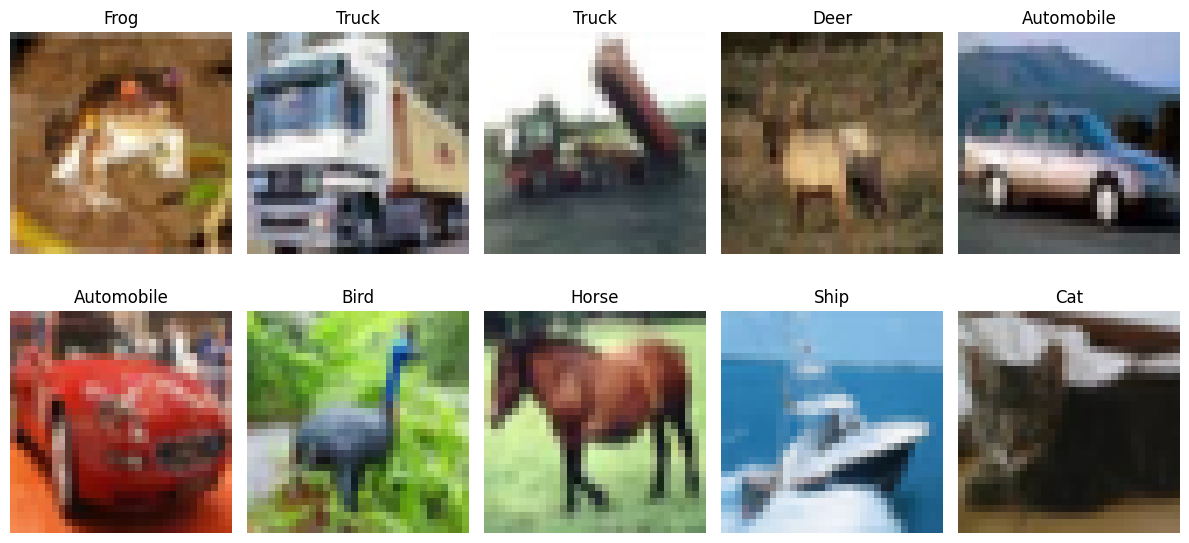

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

# Conv Block 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D((2,2)))

# Conv Block 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

# Conv Block 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4087 - loss: 1.6116 - val_accuracy: 0.5226 - val_loss: 1.3234
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5678 - loss: 1.2074 - val_accuracy: 0.6309 - val_loss: 1.0322
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6358 - loss: 1.0352 - val_accuracy: 0.6702 - val_loss: 0.9266
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6831 - loss: 0.9005 - val_accuracy: 0.6985 - val_loss: 0.8539
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7144 - loss: 0.8110 - val_accuracy: 0.7295 - val_loss: 0.7810
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7386 - loss: 0.7454 - val_accuracy: 0.7385 - val_loss: 0.7543
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7655 - loss: 0.6758 - val_accuracy: 0.7490 - val_loss: 0.7367
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7843 - loss: 0.6166 - val_accuracy: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7549 - loss: 0.9860

Test Loss: 0.9860397577285767
Test Accuracy: 0.7548999786376953


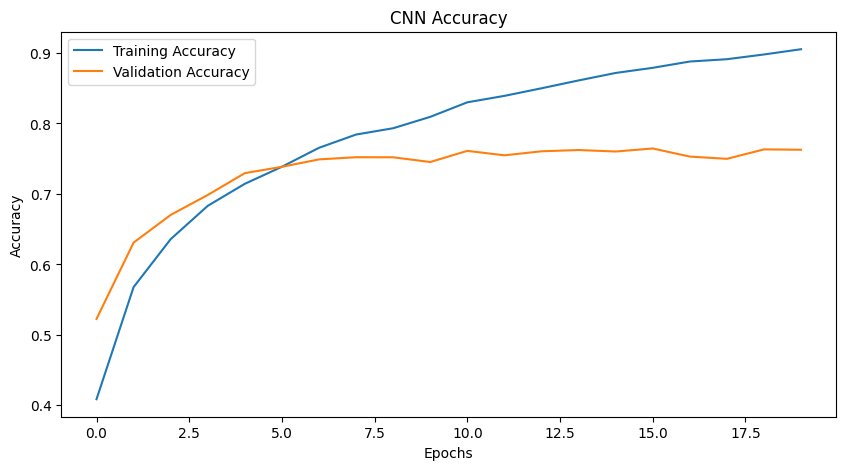

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

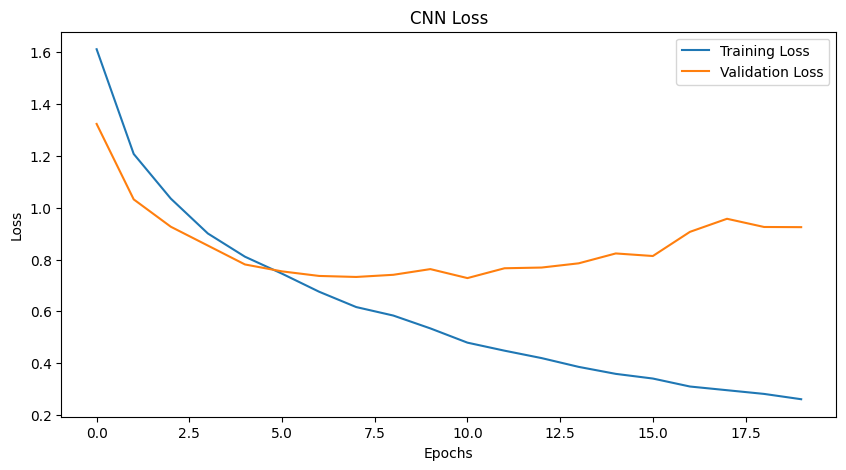

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step


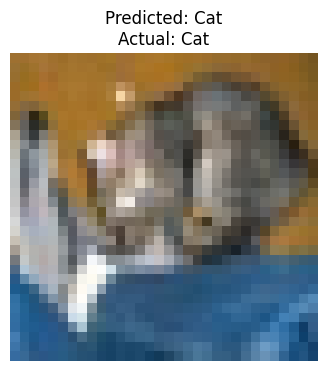

Confidence: 84.608894 %


In [ ]:
sample_index = 0

sample = X_test[sample_index]

prediction = model.predict(
    sample.reshape(1,32,32,3)
)

predicted_class = np.argmax(prediction)

actual_class = y_test[sample_index][0]

plt.figure(figsize=(4,4))
plt.imshow(sample)

plt.title(
    f"Predicted: {class_names[predicted_class]}\nActual: {class_names[actual_class]}"
)

plt.axis('off')
plt.show()

print("Confidence:", np.max(prediction)*100,"%")



In [ ]:
model.save("cifar10_cnn_model.h5")

print("Model saved successfully!")

Model saved successfully!


Saving Screenshot 2026-06-04 114040.jpg to Screenshot 2026-06-04 114040.jpg


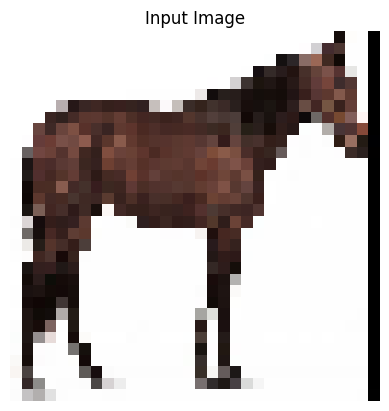

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: Horse
Confidence: 100.0 %


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (32,32))

plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

img = img.astype('float32') / 255.0

img = img.reshape(1,32,32,3)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print(
    "Predicted Class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    np.max(prediction)*100,
    "%"
)